### Additional resources

iMap ArcGIS REST Services:
https://imapinvasives.natureserve.org/arcgis/rest/

ArcGIS REST Services – Query Feature Layer documentation:
Query (Feature Service/Layer) | ArcGIS REST APIs | ArcGIS Developers
https://developers.arcgis.com/rest/services-reference/enterprise/query-feature-service-layer/

### Generate token to access ArcGIS restful API service

In [1]:
import requests

imap_session = requests.Session()

head_form = {'Content-Type' : 'application/x-www-form-urlencoded'}

##### attempt to generate token

token_request_url = "https://imapinvasives.natureserve.org/arcgis/tokens/generateToken"

auth_info_token = {
    "username": "tmollick@esf.edu",      #iMapInvasives username
    "password": "SUNY.esf@130436",       # iMapInvasives password
    "f": "json"
    }

attempt_login_token = imap_session.post(token_request_url, auth_info_token, headers=head_form)

token_response = attempt_login_token.json()

print(token_response["token"])
##########

the_token = token_response["token"]  # set the token to the response
# the_token = "uwfhss6e1V6eOjXIEjE6WeDbfrNBpPt0hQPdXI21QHUUNR2bSTp4GEmaRexLp1dG"  # or manually set it here 

clyID83Roe9eXlfVOmmogZJp6Ep3sV9BLrfnkX7XEsvvi0QsJ5y238pUhNjxXOi3


### Access the Unconfirmed iMapInvasives records by ArcGIS restful service API

In [291]:
from IPython.display import JSON, display
import requests

# Use your actual token
# the_token = "uwfhss6e1V6eOjXIEjE6WeDbfrNBpPt0hQPdXI21QHUUNR2bSTp4GEmaRexLp1dG"

# Define the request URL and parameters
unconfirmed_request_url = "https://imapinvasives.natureserve.org/arcgis/rest/services/unconfirmed_presence/MapServer/4/query"

query_params = {
    "where": "jurisdiction_species_id = 1167",
    "token": the_token,
    "f": "json",
    "outFields": "*",
    "outSR": "4326",
    "orderByFields": "present_species_id DESC",
    "resultRecordCount": 30
}

# Request the data
response = requests.get(unconfirmed_request_url, params=query_params)
unconfirmed_response = response.json()

# Display expandable JSON output
display(JSON(unconfirmed_response))


<IPython.core.display.JSON object>

### Access the Confirmed iMapInvasives records by ArcGIS restful service API

In [3]:
import requests
from IPython.display import JSON, display

# Use your actual token here
# the_token = "uwfhss6e1V6eOjXIEj6EwDbfrNBpPt0hPdX1Z1QHUUNR2bSTp4GEmaRexLp1d6"

# Correct endpoint for confirmed presence records
confirmed_request_url = "https://imapinvasives.natureserve.org/arcgis/rest/services/public_presence/MapServer/4/query"

query_params = {
    "where": "jurisdiction_species_id = 1277",   # Change the jurisdiction_species_id for different species
    "token": the_token,
    "f": "json",
    "outFields": "presence_id, present_species_id, network_species_id, jurisdiction_species_id, observer_name, jurisdiction, observation_date, scientific_name, common_name, imap_url, has_photo_ind",
    "outSR": "4326",
    "orderByFields": "present_species_id DESC",
    "resultRecordCount": 640    # Input how many records you want to extract
}

# Request the data
response = requests.get(confirmed_request_url, params=query_params)
confirmed_response = response.json()

# Display expandable JSON output
display(JSON(confirmed_response))


<IPython.core.display.JSON object>

In [375]:
import requests
from IPython.display import JSON, display

# Use your actual token here
# the_token = "your_token_here"

# Correct endpoint for confirmed presence records
confirmed_request_url = "https://imapinvasives.natureserve.org/arcgis/rest/services/public_presence/MapServer/4/query"

# List of target species IDs
target_species_ids = (1188, 1230, 1129, 1174, 1116)

# Format the list as a SQL IN clause string
species_id_filter = f"jurisdiction_species_id IN {target_species_ids}"

query_params = {
    "where": species_id_filter,
    "token": the_token,
    "f": "json",
    "outFields": "presence_id, present_species_id, network_species_id, jurisdiction_species_id, observer_name, jurisdiction, observation_date, scientific_name, common_name, imap_url, has_photo_ind",
    "outSR": "4326",
    "orderByFields": "present_species_id DESC",
    "resultRecordCount": 500    # Request 50 records in total
}

# Request the data
response = requests.get(confirmed_request_url, params=query_params)
confirmed_response = response.json()

# Display expandable JSON output
display(JSON(confirmed_response))


<IPython.core.display.JSON object>

In [5]:
import pandas as pd

# Extract and merge attributes and geometry
features = confirmed_response.get("features", [])
#features = unconfirmed_response.get("features", [])
records = []

for feature in features:
    row = feature["attributes"]
    geometry = feature.get("geometry", {})
    row["longitude"] = geometry.get("x")
    row["latitude"] = geometry.get("y")
    records.append(row)

# Convert to DataFrame
df = pd.DataFrame(records)

# Count and print number of records
print(f"Number of records: {len(df)}")

df.head()

Number of records: 640


,presence_id,present_species_id,network_species_id,jurisdiction_species_id,observer_name,jurisdiction,observation_date,scientific_name,common_name,imap_url,has_photo_ind,longitude,latitude
0,1498631,1516615,4527,1277,Carol Sobczak - 22824,New York,1748923200000,Phragmites australis ssp. australis,European Common Reed,https://imapinvasives.natureserve.org/imap/ser...,1,-78.297253,42.781128
1,1497368,1515148,4527,1277,Renee Wickman - 19513,New York,1746545071000,Phragmites australis ssp. australis,European Common Reed,https://imapinvasives.natureserve.org/imap/ser...,0,-77.939050,43.359666
2,1497366,1515146,4527,1277,Addison Kubik - 24406,New York,1745347395000,Phragmites australis ssp. australis,European Common Reed,https://imapinvasives.natureserve.org/imap/ser...,1,-73.812991,42.740223
3,1496047,1513637,4527,1277,Sam Schultz - 9924,New York,1653419739000,Phragmites australis ssp. australis,European Common Reed,https://imapinvasives.natureserve.org/imap/ser...,1,-73.942022,42.662136
4,1495913,1513498,4527,1277,Brianna Saylor - 20485,New York,1693507225000,Phragmites australis ssp. australis,European Common Reed,https://imapinvasives.natureserve.org/imap/ser...,0,-78.644206,42.597780


In [7]:
# Define observers to exclude (normalize dash types for safety)
excluded_observers = ["Daina Krummins - 20202", "Daina krummins – 15753"]

# Filter conditions
filtered_df = df[
    (df["jurisdiction"] == "New York") &
    (df["has_photo_ind"] == 1) &
    (~df["observer_name"].isin(excluded_observers))
]

# Count and print number of records
print(f"Number of filtered records: {len(filtered_df)}")

filtered_df.head()

Number of filtered records: 145


,presence_id,present_species_id,network_species_id,jurisdiction_species_id,observer_name,jurisdiction,observation_date,scientific_name,common_name,imap_url,has_photo_ind,longitude,latitude
0,1498631,1516615,4527,1277,Carol Sobczak - 22824,New York,1748923200000,Phragmites australis ssp. australis,European Common Reed,https://imapinvasives.natureserve.org/imap/ser...,1,-78.297253,42.781128
2,1497366,1515146,4527,1277,Addison Kubik - 24406,New York,1745347395000,Phragmites australis ssp. australis,European Common Reed,https://imapinvasives.natureserve.org/imap/ser...,1,-73.812991,42.740223
3,1496047,1513637,4527,1277,Sam Schultz - 9924,New York,1653419739000,Phragmites australis ssp. australis,European Common Reed,https://imapinvasives.natureserve.org/imap/ser...,1,-73.942022,42.662136
5,1495905,1513490,4527,1277,Brianna Saylor - 20485,New York,1695145869000,Phragmites australis ssp. australis,European Common Reed,https://imapinvasives.natureserve.org/imap/ser...,1,-78.008054,43.094588
6,1495904,1513489,4527,1277,Brianna Saylor - 20485,New York,1695142785000,Phragmites australis ssp. australis,European Common Reed,https://imapinvasives.natureserve.org/imap/ser...,1,-78.008387,43.095712


### Import necessary libraries

In [71]:
# import required libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

### Set Working directory

In [74]:
os.getcwd() # Get current working directory

'C:\\Users\\tmollick\\Documents\\iMapML\\Datasets'

In [76]:
os.chdir(r"C:\Users\tmollick\Documents\iMapML\Datasets") # Change current working directory

### Check files in the directory

In [79]:
os.listdir() # Check new files in the new directory

['14 Species.xlsx',
 '20240420_193116.jpg',
 '20240605_125139.jpg',
 'Eag.jpg',
 'New_York_iMap_confirmed_records_from_year_2000.csv',
 'NY_unconfirmed_imap_records.csv',
 'presence_ids_with_photos.txt']

In [81]:
# Load the Excel file
Selected_species = pd.read_excel("14 Species.xlsx")

# Convert all columns to text (string)
Selected_species["Jurisdiction species ID"] = Selected_species["Jurisdiction species ID"].astype('Int64').astype(str)

# Show the first 22 rows
Selected_species.head(22)

,Common name,Scientific name,Jurisdiction species ID,Taxon ID,Combined_score_threshold,Geo_score_mean
0,Phragmities,Phragmites australis,1277,64237,NaN,30.56
1,Phragmities,Phragmites australis ssp. australis,<NA>,556361,NaN,30.56
2,Honeysuckle,Lonicera spp. (species unknown),1358,51874,NaN,19.88
3,Honeysuckles,Lonicera maackii,1188,82342,NaN,19.88
4,Honeysuckles,Lonicera tatarica,1230,77836,NaN,19.88
5,Honeysuckles,Lonicera morrowii,1129,59773,NaN,19.88
6,Honeysuckles,Lonicera xylosteum,1174,124548,NaN,19.88
7,Honeysuckles,Lonicera x bella,1116,170851,NaN,19.88
8,Honeysuckles,Lonicera fragrantissima,<NA>,164763,NaN,19.88
9,Wild Parsnip,Pastinaca sativa,1182,59778,NaN,23.79


### Use the selected records to check by iMap API

In [9]:
record_ids = filtered_df

In [11]:
pre_ID = record_ids["presence_id"].tolist()  # Convert Series to list

### Accessing iMapInvasives API 
Create an account using https://www.imapinvasives.org/ address and use the username and password to access the iMap API
#### Use your iMap username and password in the code below to get access to the iMap API

In [14]:
import requests

imap_site = "imapinvasives"      
iMap_username = "tmollick@esf.edu"  # Replace with your iMap username
iMap_password = "SUNY.esf@130436"   # Replace with your iMap password

login_url = r"https://{0}.natureserve.org/imap/j_spring_security_check".format(imap_site)

# Attempt to log in
print("\nAttempting to authenticate with: {0}".format(login_url))
iMapSession = requests.Session()  # This is a global variable accessed in later functions
login_response = iMapSession.post(login_url,{'j_username':iMap_username,'j_password':iMap_password})
login_response_message = "\nlogin response: {0}".format(login_response.status_code)
print(login_response_message)
login_response.raise_for_status()

# Attempt to access a record to check if log-in was successful
test_aoi_url = r"https://{0}.natureserve.org/imap/services/aoi/new".format(imap_site)
test_aoi_record = iMapSession.get(test_aoi_url)
test_aoi_record_message = "\nTest record access response: {0}".format(test_aoi_record.status_code)
print(test_aoi_record_message)

if test_aoi_record.status_code == 403:
    print("\nResponse Code 403 is most likely the result of an incorrectly entered iMap username or password.  It may also be caused by logging in as a user with insufficient permissions.")

test_aoi_record.raise_for_status()


Attempting to authenticate with: https://imapinvasives.natureserve.org/imap/j_spring_security_check

login response: 200

Test record access response: 200


### Filter iMap records which have photos uploaded by users

In [17]:
base_url = f"https://{imap_site}.natureserve.org/imap/services/presence/"

# List to store presence IDs with at least one species having a photo
presence_ids_with_photos = []

# Iterate over each presence ID
for presence_id in pre_ID:
    # Construct the full URL for each presence ID
    full_url = f"{base_url}{presence_id}"
    
    # Get the iMap record for this presence ID
    try:
        imap_record = iMapSession.get(full_url)  # Use the session to maintain authentication
        
        # Check if the request was successful
        if imap_record.status_code == 200:
            # Convert the response to a dictionary
            imap_dictionary = imap_record.json()
            
            # Extract all presentSpeciesId values from the speciesList
            present_species_ids = [species.get("presentSpeciesId") for species in imap_dictionary.get("speciesList", [])]
            
            # Filter out any None values just in case
            present_species_ids = [id for id in present_species_ids if id is not None]
            
            # Check if any presentSpeciesId has hasPhotoInd == True
            has_photo = any(species.get("hasPhotoInd") == True for species in imap_dictionary.get("speciesList", []))
            
            # If at least one presentSpeciesId has a photo, add the presence ID to the list
            if has_photo:
                presence_ids_with_photos.append(presence_id)
    
    except requests.exceptions.RequestException as e:
        print(f"An error occurred while processing presence ID {presence_id}: {e}")

In [19]:
print(presence_ids_with_photos)

[1498631, 1497366, 1496047, 1495905, 1495904, 1495902, 1495901, 1495900, 1495869, 1495846, 1495845, 1495844, 1495843, 1494528, 1494524, 1494523, 1494522, 1494521, 1494520, 1492694, 1491411, 1486323, 1486322, 1486243, 1486152, 1486121, 1486090, 1481645, 1481632, 1481631, 1481630, 1481629, 1481628, 1481627, 1481626, 1481625, 1481624, 1481623, 1481610, 1478224, 1478050, 1478009, 1477370, 1476810, 1476348, 1476347, 1475982, 1475838, 1475797, 1475689, 1475687, 1475686, 1475669, 1475658, 1475657, 1475656, 1475629, 1475360, 1475354, 1475339, 1475320, 1475317, 1475316, 1475282, 1475272, 1475260, 1475230, 1475007, 1475006, 1474720, 1474655, 1474654, 1474653, 1474652, 1474651, 1474611, 1474610, 1474609, 1474465, 1474464, 1474462, 1474461, 1474460, 1474459, 1474458, 1474457, 1474456, 1474455, 1474117, 1472766, 1472759, 1472758, 1472737, 1472736, 1472735, 1472731, 1472711, 1472710, 1472709, 1472650, 1472551, 1472412, 1472290, 1472052, 1472012, 1472011, 1472010, 1471999, 1471992, 1471987, 1471984, 

In [21]:
presence_ids = presence_ids_with_photos

### Plot the first 10 iMap record photos to check


Processing presence ID: 1498631


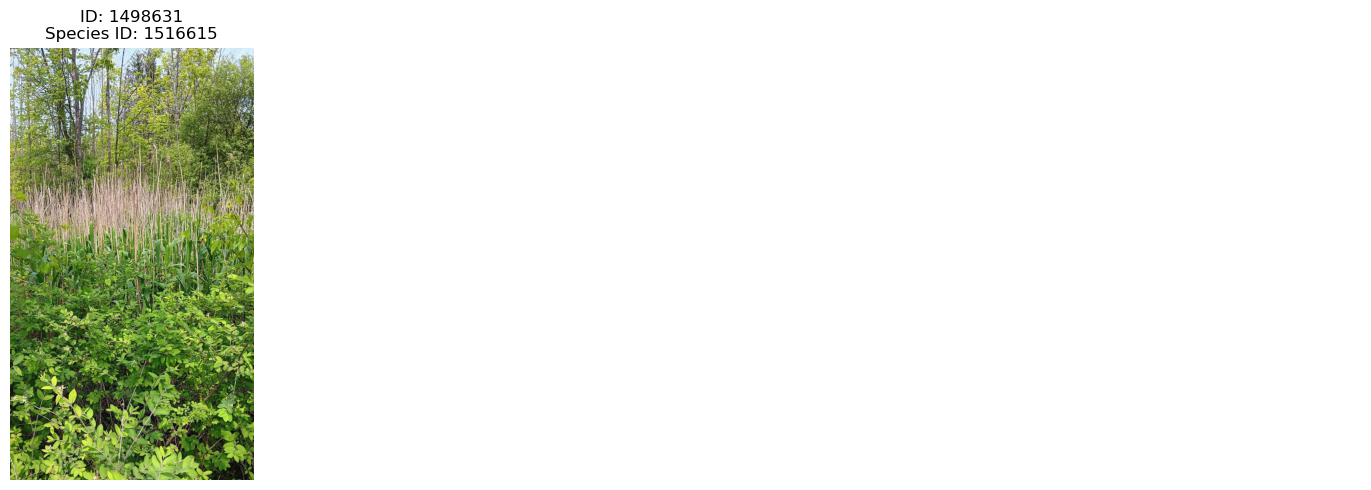


Processing presence ID: 1497366


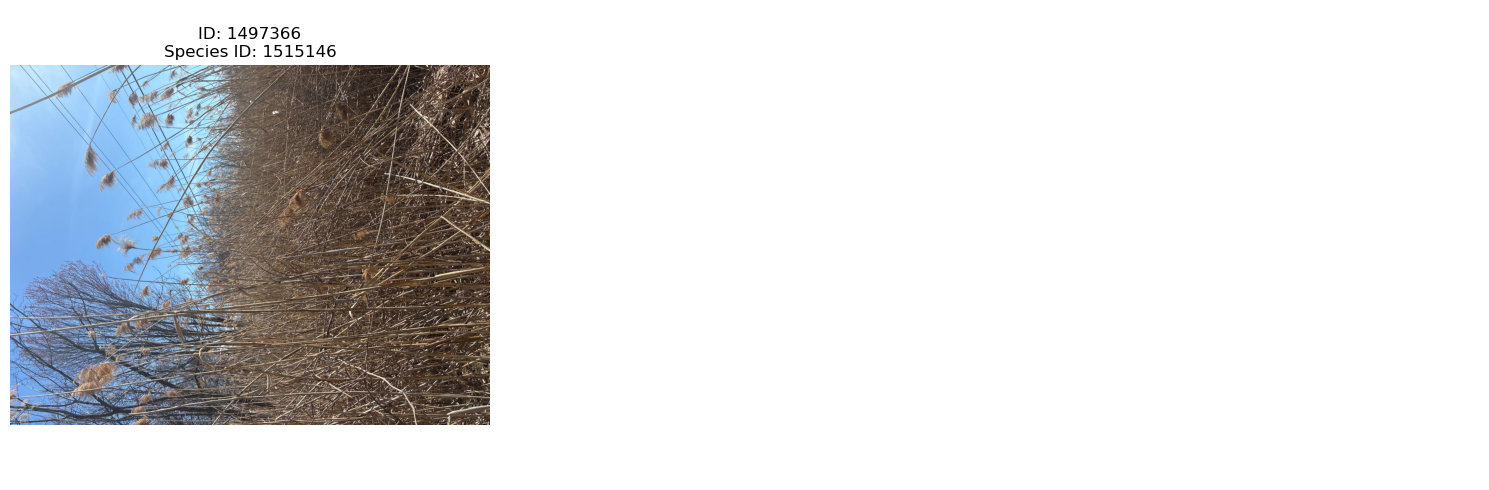


Processing presence ID: 1496047


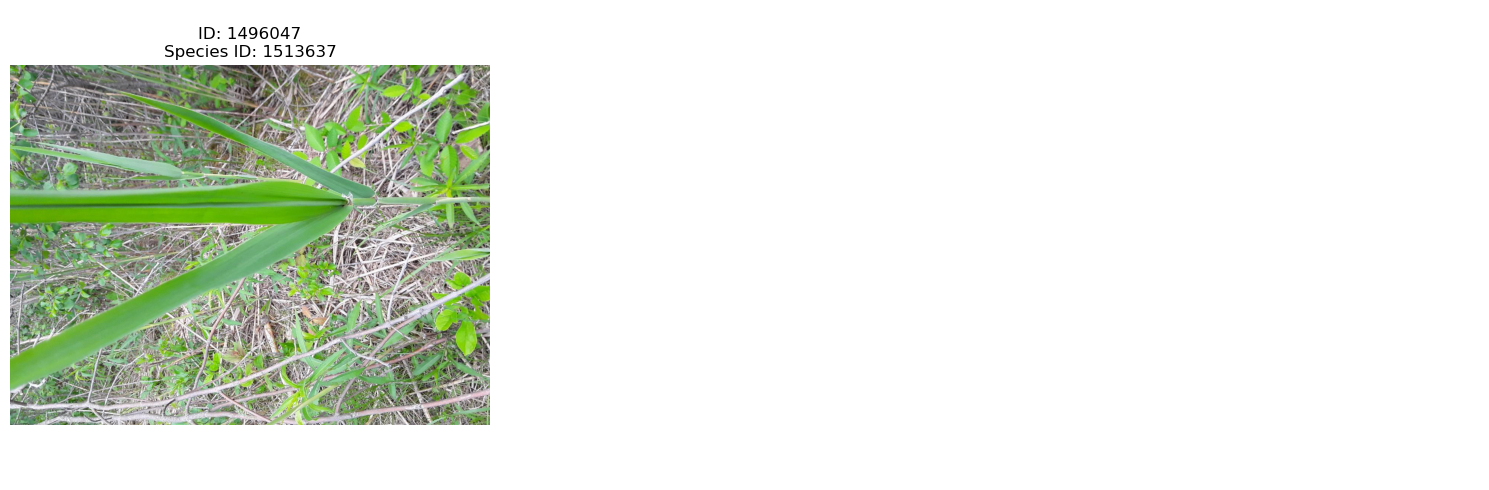


Processing presence ID: 1495905


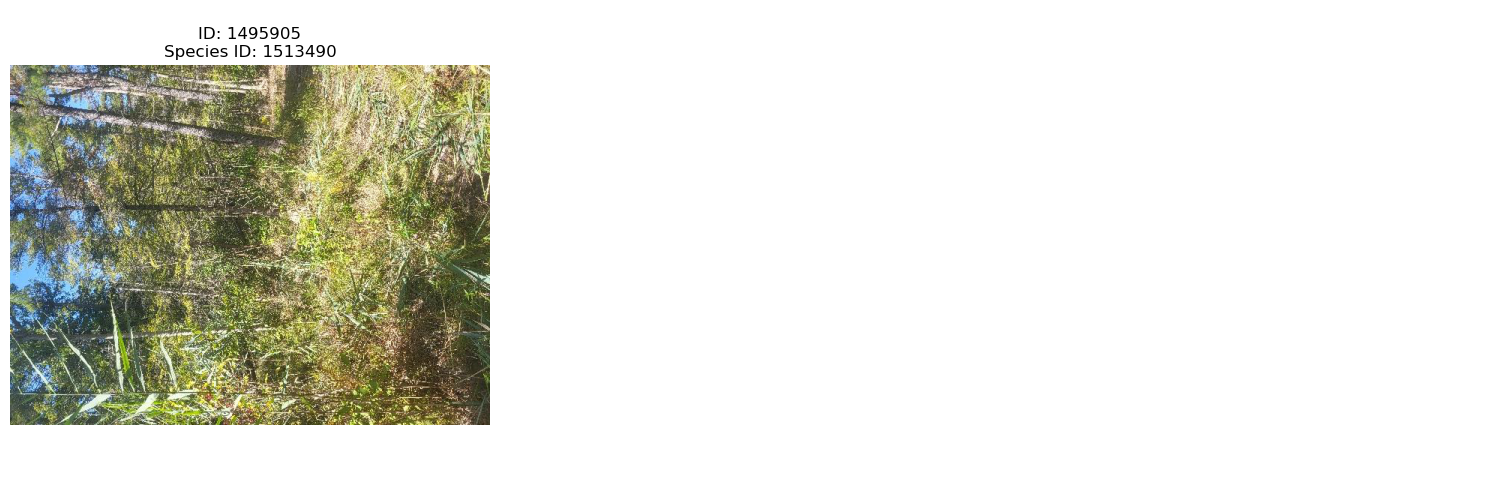


Processing presence ID: 1495904


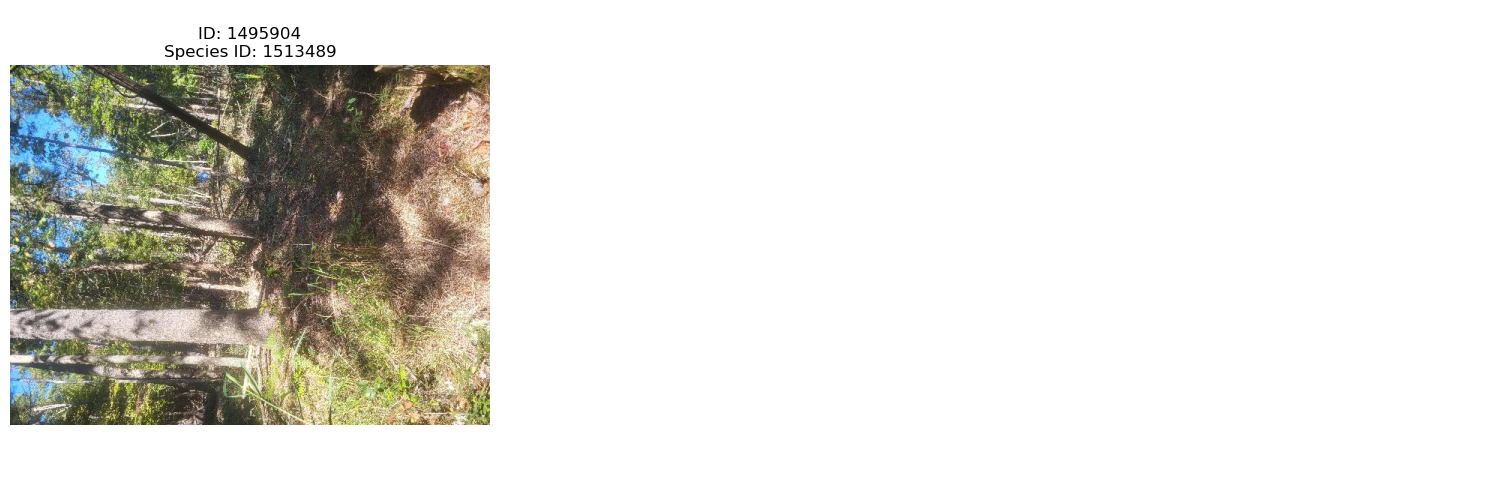


Processing presence ID: 1495902


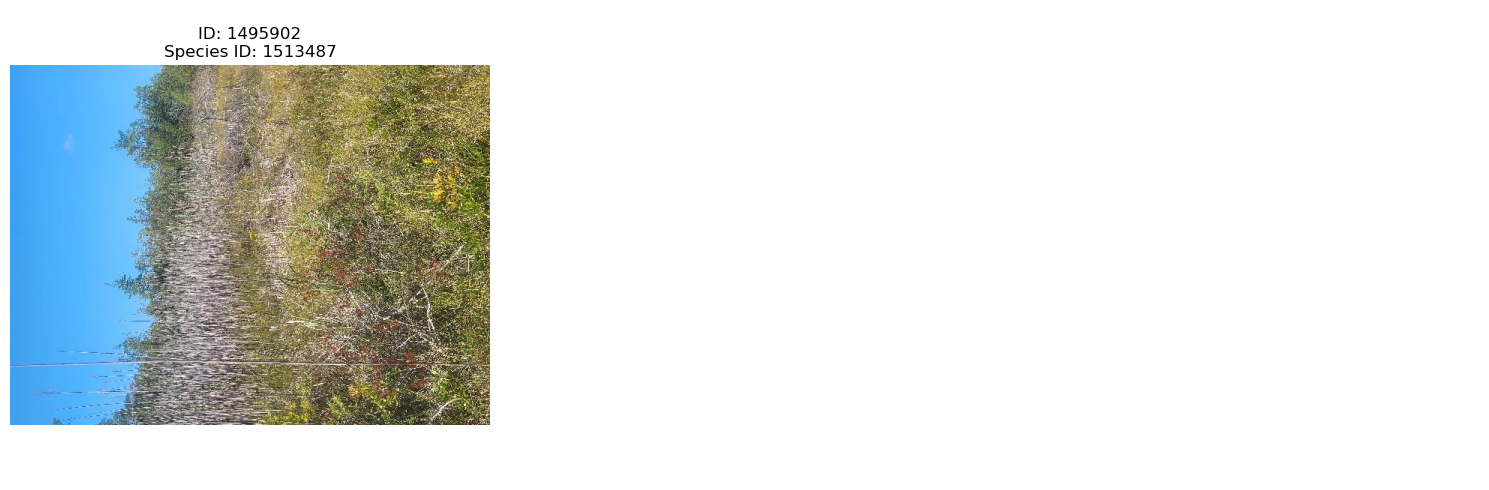


Processing presence ID: 1495901


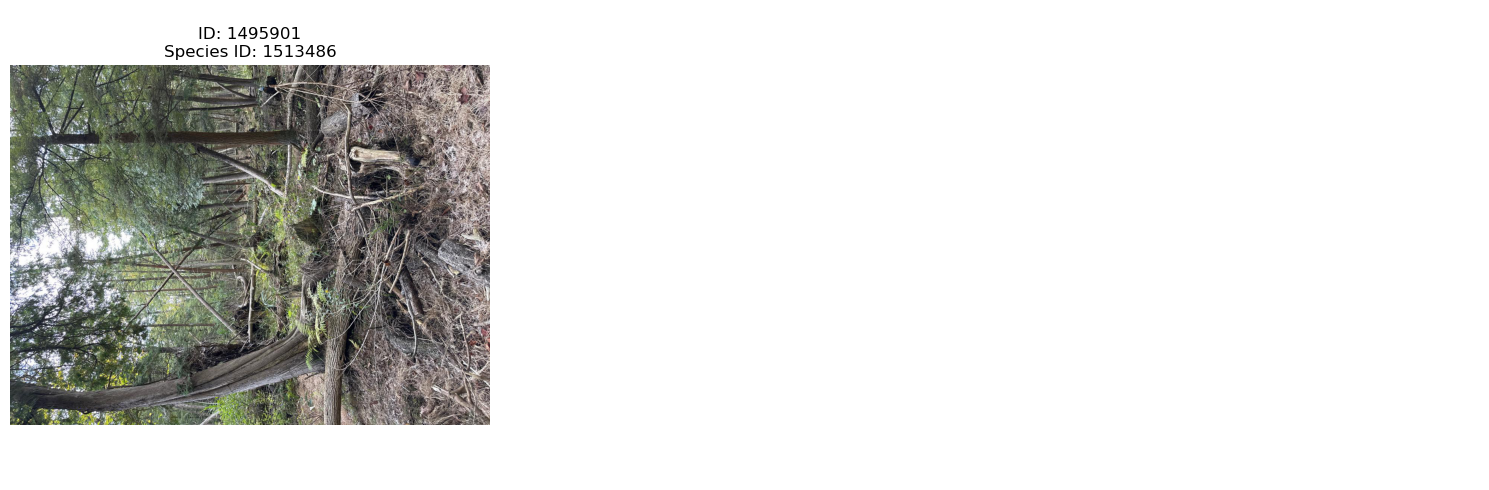


Processing presence ID: 1495900


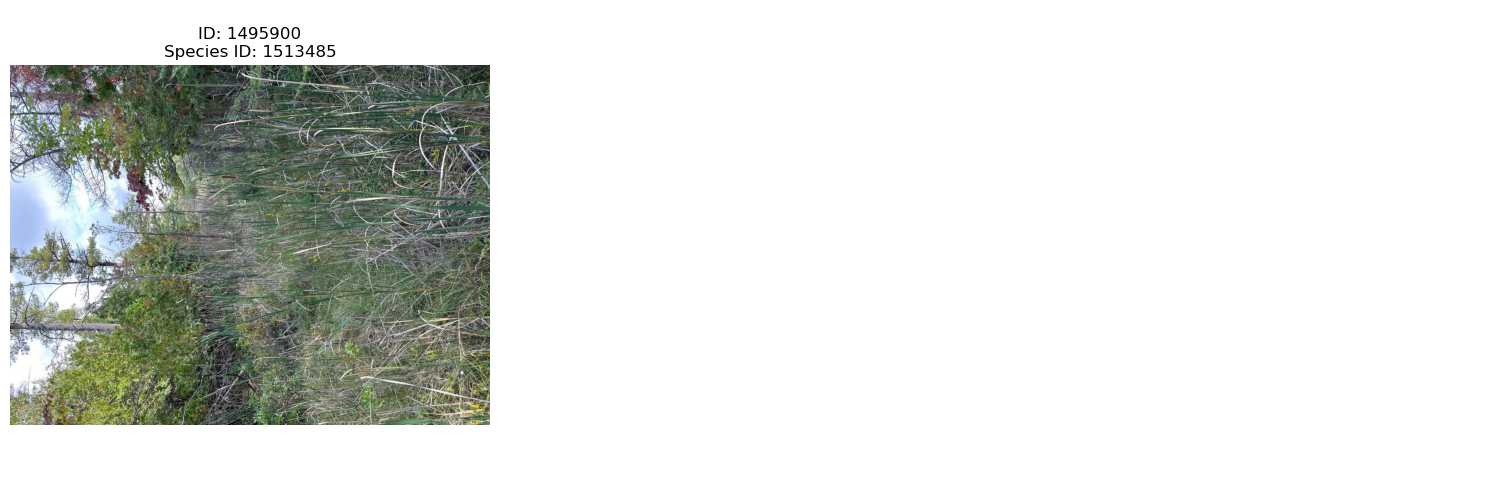


Processing presence ID: 1495869


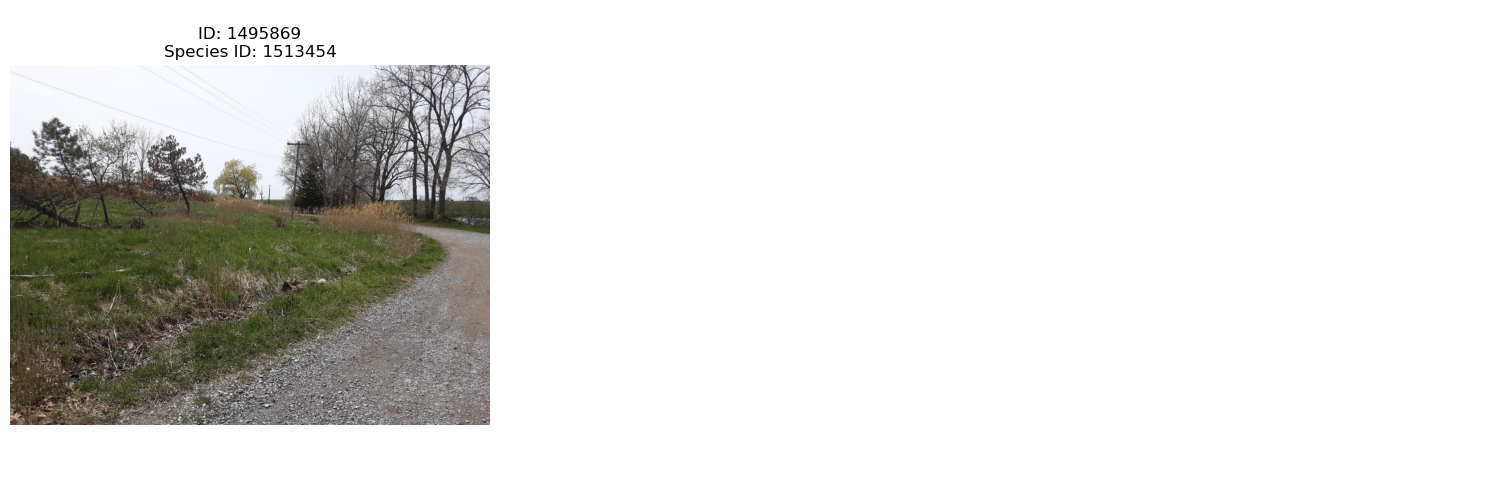


Processing presence ID: 1495846


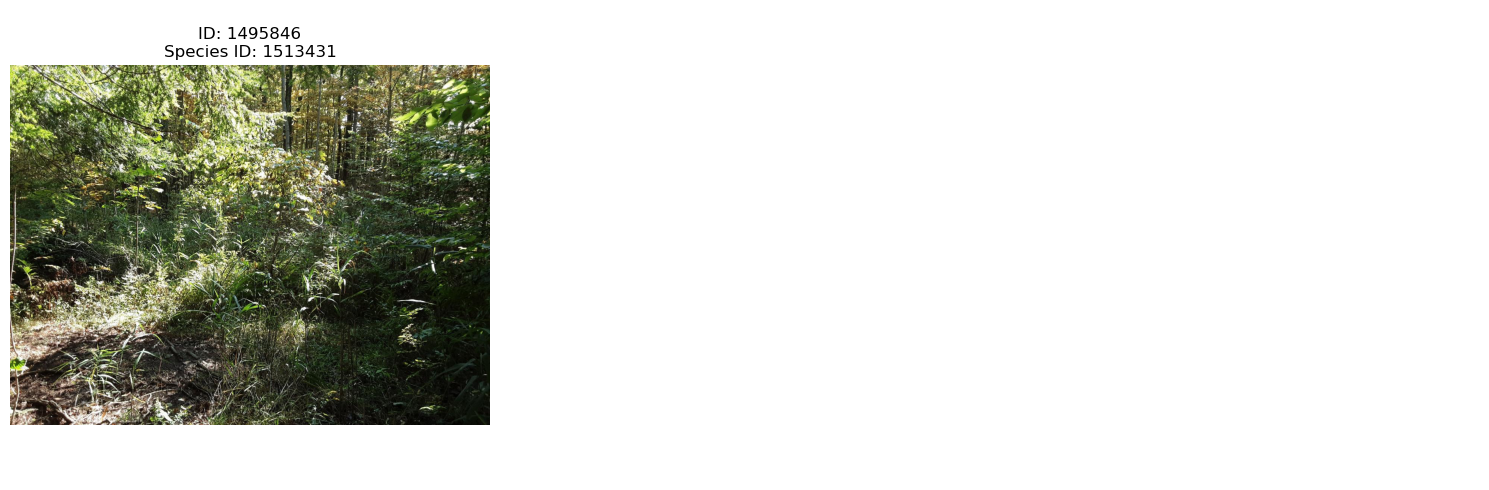

In [24]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import math

# Function to get the image from a URL, handling redirects and setting headers
def get_image_from_url(url):
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'
    }

    # Perform the GET request with headers and follow redirects
    response = iMapSession.get(url, headers=headers, allow_redirects=True)

    if response.status_code == 200:
        try:
            return Image.open(BytesIO(response.content))
        except Exception as e:
            print(f"Failed to open image. Error: {e}")
            return None
    else:
        print(f"Failed to retrieve image. Status code: {response.status_code}")
        return None

# Function to plot images for each presentSpeciesId in a grid with 3 columns
def plot_images_for_species(imap_dictionary, presence_id):
    species_list = imap_dictionary.get("speciesList", [])
    num_species = len(species_list)
    num_columns = 3
    num_rows = math.ceil(num_species / num_columns)

    fig, axs = plt.subplots(num_rows, num_columns, figsize=(15, 5 * num_rows))
    axs = axs.flatten()  # Flatten the 2D array of axes to 1D for easy iteration

    for i, species in enumerate(species_list):
        img = None

        # Check if the 'photos' list exists and has at least one item
        if "photos" in species and species["photos"]:
            photo_url = species["photos"][0].get("photoUrl", "")

            if photo_url and (photo_url.lower().endswith('.jpg') or photo_url.lower().endswith('.jpeg')):  # Ensure the URL is a valid .jpg or .jpeg
                img = get_image_from_url(photo_url)

        # Display the image if it was successfully retrieved
        if img:
            axs[i].imshow(img)
            axs[i].axis('off')  # Turn off the axis
            axs[i].set_title(f"ID: {presence_id}\nSpecies ID: {species.get('presentSpeciesId')}")
        else:
            axs[i].text(0.5, 0.5, f'ID: {presence_id}\nImage Not Available', horizontalalignment='center', verticalalignment='center')
            axs[i].axis('off')

    # Turn off remaining empty subplots
    for j in range(i + 1, num_rows * num_columns):
        axs[j].axis('off')

    plt.tight_layout()
    plt.show()

# Function to process multiple presence IDs and plot images (only first 10 records)
def plot_images_for_multiple_species_ids(presence_ids):
    base_url = "https://imapinvasives.natureserve.org/imap/services/presence/"

    # Limit to the first 10 presence IDs
    for presence_id in presence_ids[:10]:
        print(f"\nProcessing presence ID: {presence_id}")
        # Construct the full URL for each presence ID
        full_url = f"{base_url}{presence_id}"

        # Get the iMap record for this presence ID
        imap_record = iMapSession.get(full_url)

        if imap_record.status_code == 200:
            # Convert the response to a dictionary
            imap_dictionary = imap_record.json()

            # Plot images for this presence ID
            plot_images_for_species(imap_dictionary, presence_id)
        else:
            print(f"Failed to retrieve data for presence ID {presence_id}. Status code: {imap_record.status_code}")

# Process only the first 10 presence IDs and plot images
plot_images_for_multiple_species_ids(presence_ids)


### Single text file

In [26]:
# File path to save the text file
file_path = r"C:\Users\tmollick\Documents\iMapML\Datasets\presence_ids_with_photos.txt"  # Change the directory where you want to save the file

# Writing the list to a text file
with open(file_path, "w") as file:
    for number in presence_ids_with_photos:
        file.write(f"{number}\n")

print(f"File saved successfully as {file_path}")

File saved successfully as C:\Users\tmollick\Documents\iMapML\Datasets\presence_ids_with_photos.txt
